<a href="https://colab.research.google.com/github/DEESHA-AFK/T076-ARTIFICIAL-INTELLIGENCE-PRACTICAL/blob/main/T076_DEESHA_CHAVAN_AI_PRAC_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Optimal Path Discovered: Andheri Station (W) -> Navpada -> Mahim-Sion Link Rd -> Trans Hbr Link (Sewri) -> Karnala Fort
Total Road Distance: 63.5 km



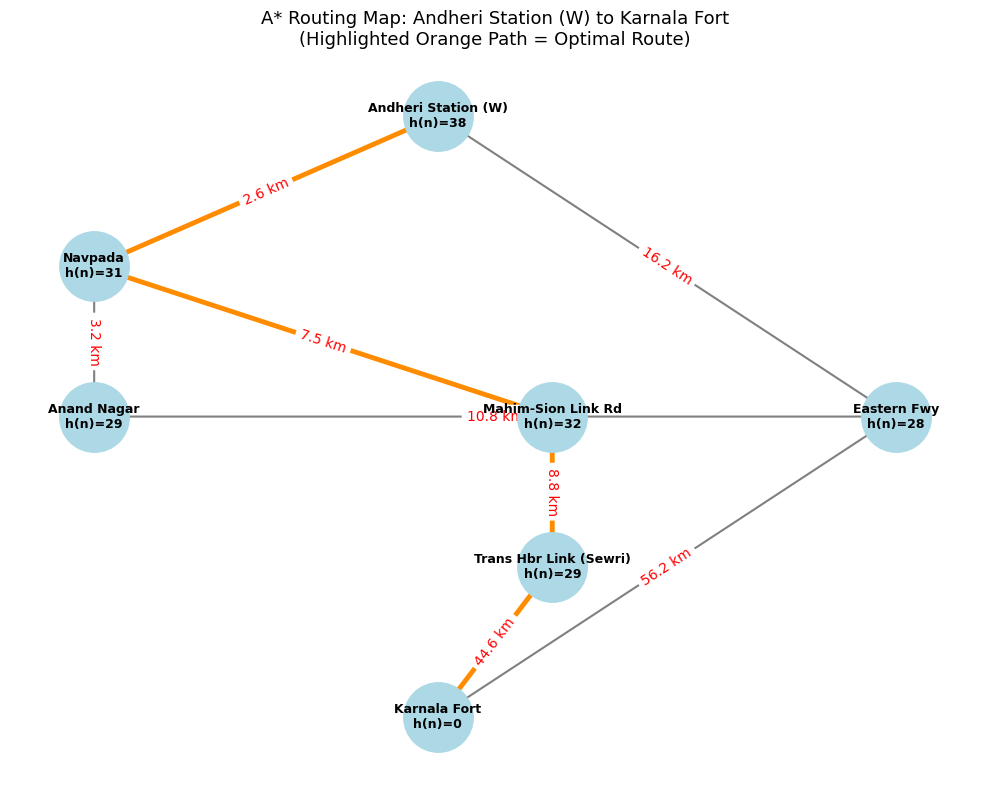

In [1]:
"""
A* Search Algorithm in AI
A* Search algorithm for solving a pathfinding problem: Andheri to Karnala Fort.
"""

import heapq
import matplotlib.pyplot as plt
import networkx as nx

#DATA STRUCTURE POPULATION
graph = {
    'Andheri Station (W)':      {'Navpada': 2.6, 'Eastern Fwy': 16.2},
    'Navpada':                  {'Anand Nagar': 3.2, 'Mahim-Sion Link Rd': 7.5},
    'Anand Nagar':               {'Eastern Fwy': 10.8},
    'Mahim-Sion Link Rd':        {'Trans Hbr Link (Sewri)': 8.8},
    'Eastern Fwy':                {'Karnala Fort': 56.2},
    'Trans Hbr Link (Sewri)':    {'Karnala Fort': 44.6},
    'Karnala Fort':               {}
}

heuristics = {
    'Andheri Station (W)': 38,
    'Navpada': 31,
    'Anand Nagar': 29,
    'Mahim-Sion Link Rd': 32,
    'Eastern Fwy': 28,
    'Trans Hbr Link (Sewri)': 29,
    'Karnala Fort': 0
}

node_positions = {
    'Andheri Station (W)':    (2, 10),
    'Navpada':                 (0.5, 7.5),
    'Anand Nagar':              (0.5, 5),
    'Mahim-Sion Link Rd':       (2.5, 5),
    'Eastern Fwy':               (4, 5),
    'Trans Hbr Link (Sewri)':    (2.5, 2.5),
    'Karnala Fort':                (2, 0)
}

#A* SEARCH ALGORITHM
def a_star_search(graph, heuristics, start, goal):
    priority_queue = [(heuristics[start], start, [start], 0)]
    visited = set()

    while priority_queue:
        f_score, current, path, g_score = heapq.heappop(priority_queue)

        if current in visited:
            continue
        visited.add(current)

        if current == goal:
            return path, g_score

        for neighbor, edge_weight in graph[current].items():
            if neighbor not in visited:
                next_g = g_score + edge_weight
                next_f = next_g + heuristics[neighbor]
                heapq.heappush(priority_queue, (next_f, neighbor, path + [neighbor], next_g))

    return None, float('inf')

optimal_path, total_distance = a_star_search(graph, heuristics, 'Andheri Station (W)', 'Karnala Fort')
print(f"Optimal Path Discovered: {' -> '.join(optimal_path)}")
print(f"Total Road Distance: {total_distance} km\n")


#GRAPH PLOTTING AND VISUALIZATION
G = nx.DiGraph()
for node, neighbors in graph.items():
    for neighbor, weight in neighbors.items():
        G.add_edge(node, neighbor, weight=weight)

plt.figure(figsize=(10, 8))

path_edges = list(zip(optimal_path, optimal_path[1:]))
normal_edges = [edge for edge in G.edges() if edge not in path_edges]

nx.draw_networkx_nodes(G, node_positions, node_size=2500, node_color='lightblue')
nx.draw_networkx_edges(G, node_positions, edgelist=normal_edges, width=1.5, edge_color='gray', arrows=True)

nx.draw_networkx_edges(G, node_positions, edgelist=path_edges, width=3.5, edge_color='darkorange', arrows=True)

node_labels = {node: f"{node}\nh(n)={heuristics[node]}" for node in G.nodes()}
nx.draw_networkx_labels(G, node_positions, labels=node_labels, font_size=9, font_weight='bold')

edge_labels = nx.get_edge_attributes(G, 'weight')
formatted_edge_labels = {k: f"{v} km" for k, v in edge_labels.items()}
nx.draw_networkx_edge_labels(G, node_positions, edge_labels=formatted_edge_labels, font_color='red')

plt.title("A* Routing Map: Andheri Station (W) to Karnala Fort\n(Highlighted Orange Path = Optimal Route)", fontsize=13)
plt.axis('off')
plt.tight_layout()
plt.savefig('a_star_andheri_karnala.png', dpi=150)
plt.show()
